# Feature Engineering

 What early signals (first 8 weeks) from trend data and customer reviews correlate with a style's seasonal peak popularity?

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR    = Path('data')
RESULTS_DIR = Path('results')

WINDOW   = 8
TS_COLS  = ['ts_mean', 'ts_slope', 'ts_curvature', 'ts_range', 'ts_peak_pos']
REV_COLS = ['rev_count', 'rev_mean_rating', 'rev_positive_frac']
TARGET   = 'actual_peak_value'

## Observation window

WINDOW = 8 means we use only the first 8 weeks of a season - exactly what a retailer has available when placing their first re-order. Everything after week 8 is the future we are trying to predict.

Why 8? It is a pragmatic trade-off: fewer weeks = earlier decision, but weaker signal.

In [21]:
trends  = pd.read_csv(DATA_DIR / 'trends_synthetic.csv', parse_dates=['date'])
reviews = pd.read_csv(DATA_DIR / 'reviews_synthetic.csv')
truth   = pd.read_csv(RESULTS_DIR / 'peak_ground_truth.csv')

STYLE_NAMES = truth['style'].unique().tolist()
N_YEARS     = int(truth['year'].nunique())
print(f'Styles: {len(STYLE_NAMES)}, Years: {N_YEARS}, Instances: {len(STYLE_NAMES) * N_YEARS}')

Styles: 8, Years: 6, Instances: 48


## Sample size

48 instances (8 styles × 6 years) - a small dataset for machine learning. This places real limits on what we can reliably detect:

- Walk-forward CV with 4 folds yields only 32 test instances (8 styles × 4 test years).
- A 1–2 pt difference in MAE may be within noise at this scale.

In [22]:
def ts_features(year_series: np.ndarray, window: int = WINDOW) -> dict:
    """Extract shape features from the first `window` weeks of a yearly series.
    """
    w = year_series[:window].astype(float)
    t = np.arange(window, dtype=float)
    slope, _   = np.polyfit(t, w, 1)
    a2, _, _   = np.polyfit(t, w, 2)
    return {
        'ts_mean':      float(np.mean(w)),
        'ts_slope':     float(slope),
        'ts_curvature': float(a2),
        'ts_range':     float(np.max(w) - np.min(w)),
        'ts_peak_pos':  int(np.argmax(w)),
    }


def rev_features(df_rev: pd.DataFrame, style: str, year: int, window: int = WINDOW) -> dict:
    """Extract review signals from the first `window` weeks of a season.
    """
    mask = ((df_rev['style'] == style) & (df_rev['year'] == year)
            & (df_rev['week_in_year'] <= window))
    sub  = df_rev.loc[mask]
    if len(sub) == 0:
        return {'rev_count': 0, 'rev_mean_rating': 0.0, 'rev_positive_frac': 0.0}
    return {
        'rev_count':         len(sub),
        'rev_mean_rating':   float(sub['rating'].mean()),
        'rev_positive_frac': float((sub['rating'] >= 4).mean()),
    }

## Why these features?

Time-series features from weeks 1-8:

Feature & What it captures 
- ts_mean - Average level - proxy for this year's baseline popularity 
- ts_slope - Rate of change - is the style gaining or losing momentum? 
- ts_curvature - Acceleration - is the pace itself speeding up or slowing? 
- ts_range - Amplitude - early-season volatility 
- ts_peak_pos - Which of the 8 weeks holds the maximum 

Review features from the same window:

- rev_count - Early buzz volume 
- rev_mean_rating - Buyer sentiment - partially encodes the hidden buzz factor 
- rev_positive_frac - Fraction of ratings ≥ 4 - more robust to outlier ratings than the mean 

Why shape features over lag features? A natural alternative is an autoregressive (AR) approach — using lagged values $y_{t-1}, y_{t-2}, \ldots$ as features. We chose shape descriptors (slope, curvature, mean) instead because:

1. With only 8 observations per window, $\text{polyfit}$ extracts the global trend efficiently without needing a separate lag for each time step.
2. Shape features are more interpretable - a retailer can act on "the style is accelerating in week 3" more easily than "the lag-4 coefficient is positive".
3. They generalise better across styles with different seasonal shapes.

The within-style Pearson $r$ values printed below show how strongly each feature correlates with the seasonal peak after removing the between-style level.

In [23]:
records = []
for _, row in truth.iterrows():
    style    = row['style']
    year     = int(row['year'])
    peak_val = float(row['actual_peak_value'])
    year_series = trends.loc[trends['year'] == year, style].values
    feats = ts_features(year_series, WINDOW)
    feats.update(rev_features(reviews, style, year, WINDOW))
    feats['style']             = style
    feats['year']              = year
    feats['actual_peak_value'] = peak_val
    records.append(feats)

features = pd.DataFrame(records)
features = features[TS_COLS + REV_COLS + ['style', 'year', TARGET]]
features.to_csv(RESULTS_DIR / 'features.csv', index=False)

# Data validation 
assert features.shape[0] == 48, \
    f"Expected 48 instances (8 styles × 6 years), got {features.shape[0]}"
assert features[TARGET].isna().sum() == 0, \
    "Missing values detected in target column"
assert (features[TS_COLS + REV_COLS].isna().sum() == 0).all(), \
    "Missing values detected in feature columns"
assert ((features['ts_peak_pos'] >= 0) & (features['ts_peak_pos'] < WINDOW)).all(), \
    "ts_peak_pos out of valid range [0, WINDOW)"
print("All data validation checks passed.")

print(f'\nfeatures.csv written — {features.shape}')
print()
# Within-style correlation (demeaned) - the relevant signal for the models
print('Within-style Pearson r with actual_peak_value:')
for col in TS_COLS + REV_COLS:
    actual_peak_value = features.copy()
    actual_peak_value['feat_dm'] = actual_peak_value.groupby('style')[col].transform(lambda x: x - x.mean())
    actual_peak_value['tgt_dm']  = actual_peak_value.groupby('style')[TARGET].transform(lambda x: x - x.mean())
    r = float(np.corrcoef(actual_peak_value['feat_dm'], actual_peak_value['tgt_dm'])[0, 1])
    print(f'  {col:25s}: {r:+.3f}')

All data validation checks passed.

features.csv written — (48, 11)

Within-style Pearson r with actual_peak_value:
  ts_mean                  : +0.748
  ts_slope                 : -0.026
  ts_curvature             : -0.020
  ts_range                 : +0.089
  ts_peak_pos              : +0.044
  rev_count                : +0.198
  rev_mean_rating          : +0.328
  rev_positive_frac        : +0.204


## Within-style correlation - the key signal

The global Pearson r between ts_mean and actual_peak_value is high (~0.51) - but mainly because different styles sit at very different levels. The baseline (per-style historical mean) already captures this between-style variation perfectly.

The relevant signal is the within-style r after removing each style's mean: r(ts_mean, peak) ≈ +0.75. If a style's early weeks are above its own historical average, the season's peak will likely be above it too.

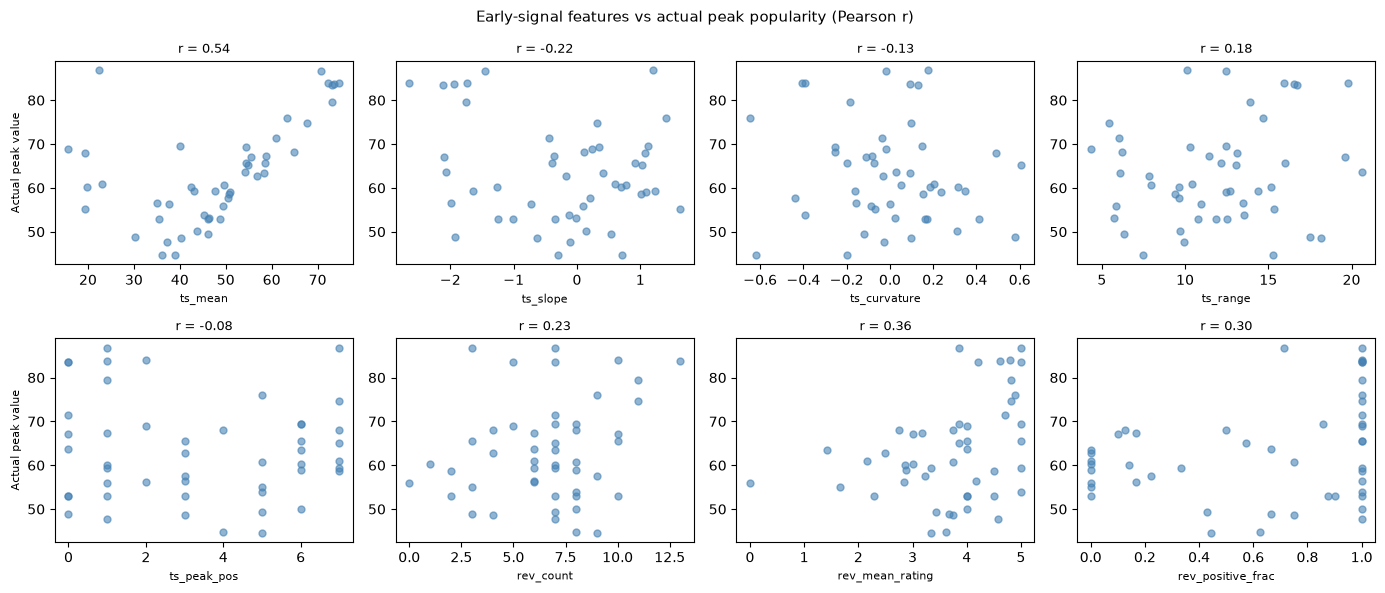

In [24]:
all_feat_cols = TS_COLS + REV_COLS
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(all_feat_cols):
    ax = axes[i]
    ax.scatter(features[col], features[TARGET],
               alpha=0.6, s=25, color='steelblue')
    r = float(np.corrcoef(features[col], features[TARGET])[0, 1])
    ax.set_title(f'r = {r:.2f}', fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    if i % 4 == 0:
        ax.set_ylabel('Actual peak value', fontsize=8)

for j in range(len(all_feat_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Early-signal features vs actual peak popularity (Pearson r)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_features.png', dpi=100)
plt.show()

## Scatter plot takeaway

ts_mean is the strongest single predictor globally (r ≈ 0.51), but the scatter shows two layers: the large between-style spread (captured by the baseline) and the smaller within-style variation (what Model A adds on top). The review features show r ≈ 0.2-0.4 - weaker, but potentially non-redundant if they encode the buzz factor independently of the trend line. Notebook 02 tests this directly by comparing models with and without review features.